<a href="https://colab.research.google.com/github/MGentieu/Challenge_welding/blob/main/01-Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial notebook

This notebook shows:
- how to use main user functions to manipulate the datasets
- familiarize the participants with the use case
- provide some tools to visulaize the use case's data

### Prerequisites
Install the dependencies if not already done. For more information look at the [readme](../README.md) file.

##### For development on Local Machine

In [ ]:
### Install a virtual environment
# Option 1:  using conda (recommended)
# !conda create -n venv python=3.12
# !conda activate venv

# Option 2: using virtualenv
# !pip install virtualenv
# !virtualenv -p /usr/bin/python3.12 venv
# !source venv_lips/bin/activate

##### For Google Colab Users
You could also use a GPU device from Runtime > Change runtime type and by selecting T4 GPU.

In [1]:
### Install the welding challenge package
# Option 1: Get the last version of challenge welding package framework from PyPI (Recommended)
!pip install 'challenge-welding'

In [2]:
import os
import sys
from pathlib import Path

# Detect working directory
cwd = Path.cwd().resolve()

# If in Colab (/content), search for repo folder automatically
if cwd.name == "content":
    # Look for the cloned project automatically
    candidates = [d for d in cwd.iterdir() if d.is_dir() and "welding" in d.name.lower()]

    if not candidates:
        raise FileNotFoundError(
            f"Aucun dossier contenant 'welding' trouvé dans /content.\n"
            f"Dossiers présents : {os.listdir(cwd)}"
        )

    PROJECT_ROOT = candidates[0]
else:
    PROJECT_ROOT = cwd

print(f"Detected project root: {PROJECT_ROOT}")

# Validate directory
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Missing directory at {PROJECT_ROOT}")

# Add to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Detected project root: /content/Challenge_welding


In [ ]:
# Option 2: Get the last version from github repository
# !git clone https://github.com/confianceai/Challenge-Welding-Starter-Kit
# !pip install -U .

Attention: You may restart the session after this installation, in order that the changes be effective.

In [3]:
import sys
import challenge_welding

## Introduction: What is the Welding Quality Detection?

In the highly competitive automotive industry, quality control is essential to ensuring vehicle reliability and user safety. A failure in quality control can severely compromise safety, lead to significant financial losses, and cause substantial reputational damage to the company involved.

One of the key challenges is improving the reliability of quality control for welding seams in automotive body manufacturing. Currently, this inspection is consistently performed by a human operator due to legal requirements related to user safety. However, during the industrial process, this task is resource-intensive. The main challenge is to develop an AI-based solution that reduces the number of inspections required by the operator through automated pre-validation.

See an example of welding below:

<div>
<img src="https://github.com/MGentieu/Challenge_welding/blob/main/docs/imgs/hero_image_3D.png?raw=1" width="500"/>
</div>


Within the [Confiance.ai](https://www.confiance.ai/) Research Program, Renault Group and SystemX have collaborated on developing trustworthy AI components to address this challenge. Now part of the [European Trustworthy Foundation (ETF)](https://www.confiance.ai/foundation/), our goal is to ensure that these tools effectively validate proposed AI models according to the trustworthy criteria defined by the industry (Intended Purpose).

This industrial use case, provided by Renault Group, ocuses on the “Visual Inspection” theme through a classification problem.

The objective is to assess weld quality based on photos taken by cameras on vehicle production lines.

A weld can have two distinct states:
- OK: The welding is normal.
- KO: The welding has defects.

Below are some examples of `OK` and `KO` welds on two different seams `c10` and `c19`.

<div>
<img src="https://github.com/MGentieu/Challenge_welding/blob/main/docs/imgs/welding_examples.png?raw=1" width="500"/>
</div>

The main goal of the challenge is to **develop an AI component (see [Notebook 3](03-Evaluate_solution.ipynb)) that assists operators in performing weld classification while minimizing the need for manual image inspection and double-checking of classifications**.

For defect identification (KO), the system should provide operators with relevant information on the location of the detected defect in the image, thereby reducing the time spent on the control task.

## Load and manipulate the data

In [4]:
"""
This script is a tutorial example of how to use of ChallengeWelding-UI functions
"""
# sys.path.insert(0, "..") # Uncomment this line For local tests without pkg installation, to make challenge_welding module visible
from challenge_welding.user_interface import ChallengeUI
from matplotlib import pyplot as plt

### Init the user interface and list available datasets
The dataset contains 22,851 images split across three different welding seams. An important feature of this dataset is its high unbalance. There are only 500 KO images in the entire dataset. *A dataset is considered a list of samples. In this challenge , a sample is a single image.*

We begin by listing the available datasets:
- `example_mini_dataset`: A demo version of the complete dataset used for demonstration, containing 2,857 images.
- `welding-detection-challenge-dataset`: The complete dataset to be used by the participants, containing 22,851 images.

See [this docoumentation](../docs/Dataset_description.md) for more information concerning the datasets and their properties.

In [5]:
# Initiate the user interface
my_challenge_UI=ChallengeUI(cache_strategy="local",cache_dir="notebooks_cache")

# Get list of available datasets
ds_list=my_challenge_UI.list_datasets()
print(ds_list)

['example_mini_dataset', 'welding-detection-challenge-dataset']


### Display the dataset metadata
Create a pandas dataframe containing metadata of all samples.

In [6]:
# We choose here the dataset named "example_mini_dataset"
ds_name='welding-detection-challenge-dataset'

# the complete dataset
# ds_name="welding-detection-challenge-dataset"

# Load all metadata of your dataset as a pandas dataframe
meta_df=my_challenge_UI.get_ds_metadata_dataframe(ds_name)

display(meta_df)

https://minio-storage.apps.confianceai-public.irtsysx.fr/challenge-welding/datasets/welding-detection-challenge-dataset/metadata/ds_meta.parquet


,sample_id,class,timestamp,welding-seams,labelling_type,resolution,path,sha256,storage_type,data_origin,blur_level,blur_class,luminosity_level,external_path
0,data_37966,OK,08/07/2022 02:05,c33,operator,"[960, 540]",challenge-welding/datasets/welding-detection-c...,b'0F\\\x12\xa1\x81\xcdL\xc3~\xbe\x03\xc90\x91\...,s3,real,1667.425860,clean,51.079433,http://minio-storage.apps.confianceai-public.i...
1,data_25403,OK,19/07/2022 00:51,c102,operator,"[960, 540]",challenge-welding/datasets/welding-detection-c...,b'\tlM\xd7\x83\\\x7fm\xaeV\xc6\xbd\xd6S@\x17S\...,s3,real,868.574712,blur,32.825601,http://minio-storage.apps.confianceai-public.i...
2,data_27038,OK,28/07/2022 16:08,c102,operator,"[960, 540]",challenge-welding/datasets/welding-detection-c...,b'\xeb\xba/\xe0-\xe6\x14\xd6\xe0\xf2oT\xd1\xa9...,s3,real,1078.402671,clean,35.192525,http://minio-storage.apps.confianceai-public.i...
3,data_8767,OK,31/01/20 09:41,c33,expert,"[1920, 1080]",challenge-welding/datasets/welding-detection-c...,"b""\x9e@!\xd3\xdd\xaa'\xb7]\xeb\xf7B\x800\xf1\x...",s3,real,1240.198851,clean,38.510588,http://minio-storage.apps.confianceai-public.i...
4,data_4744,OK,25/11/19 21:57,c20,expert,"[1920, 1080]",challenge-welding/datasets/welding-detection-c...,"b'\x0c\xd8\xcfb\x95\\\xb9\xa8w\xe7^\xea\rX,8\x...",s3,real,3371.897144,clean,46.001366,http://minio-storage.apps.confianceai-public.i...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22748,data_66456,OK,29/10/19 01:33,c102,expert,"[1920, 1080]",challenge-welding/datasets/welding-detection-c...,b'\x9fZ^\xc5j\xf1\xd8JRw\x03\xa4C\x04\xa6\xa1\...,s3,real,4463.079210,clean,41.554284,http://minio-storage.apps.confianceai-public.i...
22749,data_24294,OK,07/07/2022 01:40,c102,operator,"[960, 540]",challenge-welding/datasets/welding-detection-c...,b'\x05\x07x\xa4\xb8\x01\xf1a\x18.\x13\xe4\xe6\...,s3,real,859.194594,blur,31.966749,http://minio-storage.apps.confianceai-public.i...
22750,data_25568,OK,19/07/2022 11:59,c102,operator,"[960, 540]",challenge-welding/datasets/welding-detection-c...,b'O\x0eT\xa1\x8b\xa0\xf5\xaei\x81\xe8\x16\x96p...,s3,real,977.316444,clean,40.872106,http://minio-storage.apps.confianceai-public.i...
22751,data_39356,OK,13/07/2022 06:45,c33,operator,"[960, 540]",challenge-welding/datasets/welding-detection-c...,b'\x1bh\xd9\x8aK\x88\xc1\xcb\xea\xff\xe3]{\x0e...,s3,real,1653.447154,clean,50.429395,http://minio-storage.apps.confianceai-public.i...


### Exploration of dataset properties




You may want to see the different type resolution of image in the dataset

In [7]:
meta_df["resolution"]=meta_df["resolution"].astype(str)
meta_df["resolution"].value_counts()

,count
resolution,
[1920 1080],14991
[960 540],7762


With this dataframe you can explore, and draw statistics. For example, you can compute the repartition of weld class

In [8]:
meta_df["class"].value_counts()

,count
class,
OK,22259
KO,494


You may  want to see the class distribution for each welding-seams , or the blur distributoin

In [9]:
meta_df.groupby(["welding-seams","class"]).count()["sample_id"]

welding-seams  class
c102           KO        143
               OK       8809
c20            KO        228
               OK       4670
c33            KO        123
               OK       8780
Name: sample_id, dtype: int64

In [10]:
meta_df.groupby(["welding-seams","blur_class"]).count()["sample_id"]

welding-seams  blur_class
c102           blur          3609
               clean         5343
c20            blur           293
               clean         4605
c33            blur          3097
               clean         5806
Name: sample_id, dtype: int64

Or you may want ot see the distribiution of blur level and luminosity overs each welding-seams

In [11]:
meta_df.groupby(["welding-seams"])[["blur_level","luminosity_level"]].describe()

blur_level                                                     \
                   count         mean          std         min          25%   
welding-seams                                                                 
c102              8952.0  1650.720369  1005.945789  254.780898   836.952678   
c20               4898.0  2293.696763   930.814776   91.069600  1595.412497   
c33               8903.0  1297.613308   664.435529   23.230028   636.256059   

                                                     luminosity_level  \
                       50%          75%          max            count   
welding-seams                                                           
c102           1138.622222  2337.171499  6087.014195           8952.0   
c20            2241.619446  2932.723105  6162.044889           4898.0   
c33            1526.251062  1863.340455  3234.148671           8903.0   

                                                                     \
                    mean       std        min        25%        50%   
welding-seams                                                         
c102           39.318954  4.295224  31.157637  35.938632  39.258415   
c20            47.138129  1.367735  42.639681  46.340735  47.061283   
c33            45.560369  5.491104  13.712589  41.079870  46.648738   

                                     
                     75%        max  
welding-seams                        
c102           42.555546  51.931898  
c20            47.832960  53.476292  
c33            50.102286  57.451128

## Display an image
### Open an image
In this section we open a specific sample from the dataset, and display it

In [12]:
sample_idx=56 # idx of tested image in the dataset.
sample_meta=meta_df.iloc[sample_idx] # Get medata of image at index sample_idx

print("opening image metadata with idx ..", sample_idx)
print(sample_meta.to_dict())

img=my_challenge_UI.open_image(sample_meta["path"]) # Always Use external_path of sample to open the image

print("size of the opened image", img.shape)

opening image metadata with idx .. 56
{'sample_id': 'data_69869', 'class': 'OK', 'timestamp': '31/07/20 01:49', 'welding-seams': 'c102', 'labelling_type': 'expert', 'resolution': '[1920 1080]', 'path': 'challenge-welding/datasets/welding-detection-challenge-dataset/c102/OK/expert/sample_56.jpeg', 'sha256': b'm\xa3\x12V\xe6\x80?\xbe>\xaa\x9b\x08\xbe\x19\x8e\xc6`\xf2\x03\x86\xa4G\xe5?\xc2\xa2\xfd5t68\xa2', 'storage_type': 's3', 'data_origin': 'real', 'blur_level': 1674.16070431, 'blur_class': 'clean', 'luminosity_level': 36.85536965171871, 'external_path': 'http://minio-storage.apps.confianceai-public.irtsysx.fr/challenge-welding/datasets/welding-detection-challenge-dataset/c102/OK/expert/sample_56.jpeg'}
size of the opened image (1080, 1920, 3)


### Display the image
We can simply visualize the opened the image using `matplotlib` library.

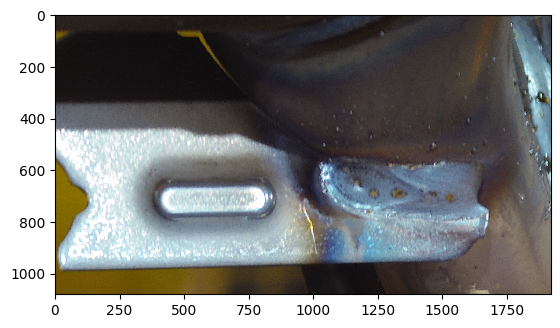

In [13]:
plt.imshow(img, interpolation='nearest')
plt.show()

You can also the already provided `display_image` function to display directly the required sample

opening image metadata with idx .. 129
{'sample_id': 'data_68894', 'class': 'OK', 'timestamp': '08/06/20 11:46', 'welding-seams': 'c102', 'labelling_type': 'expert', 'resolution': '[1920 1080]', 'path': 'challenge-welding/datasets/welding-detection-challenge-dataset/c102/OK/expert/sample_129.jpeg', 'sha256': b'N\xd7\xb9[~\xf1H#\xdc:G`\xb8\x18\xdb\x0b\x0fJ\x8d{f\xe6\x8d\xc0@\xf3{\xe2\xa7\xa8\xc6f', 'storage_type': 's3', 'data_origin': 'real', 'blur_level': 1022.6063535599999, 'blur_class': 'clean', 'luminosity_level': 43.59495563271605, 'external_path': 'http://minio-storage.apps.confianceai-public.irtsysx.fr/challenge-welding/datasets/welding-detection-challenge-dataset/c102/OK/expert/sample_129.jpeg'}
size of the opened image (1080, 1920, 3)


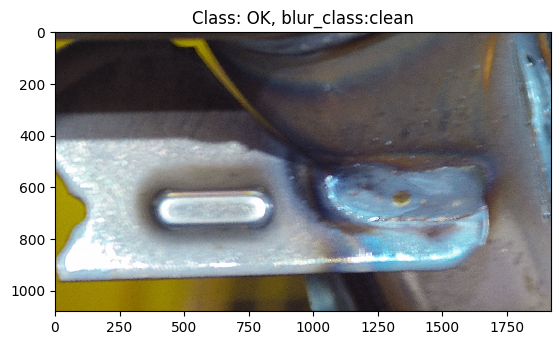

In [14]:
img = my_challenge_UI.display_image(meta_df, index=129, show_info=True)

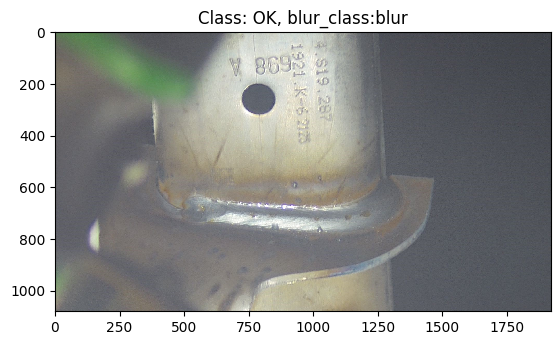

In [15]:
img = my_challenge_UI.display_image(meta_df, index=134, show_info=False)

## Check dataset integrity

Get the sha256 of each image file and compare it to those stored in its metadata. All anomalies ares stored in a Yaml file named  anomalous_samples_list.yml and returned as output of the method check_integrity() .

In [16]:
# Check integrity of all files in your dataset (this may take a while . .)

anomalie_list=my_challenge_UI.check_integrity(ds_name)

Begin checking integrity of dataset :  welding-detection-challenge-dataset  . . . 


  0%|          | 12/22753 [00:10<5:28:36,  1.15it/s]


KeyboardInterrupt: 